<a href="https://colab.research.google.com/github/Drakie444/Machine-Learning/blob/main/weather_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installl all requirements

In [23]:
!pip install google-ml-edu==0.1.3 \
  keras~=3.8.0 \
  matplotlib~=3.10.0 \
  numpy~=2.0.0 \
  pandas~=2.2.0 \
  tensorflow~=2.18.0

print('\n\nAll requirements successfully installed.')



All requirements successfully installed.


# Required imports

In [58]:
# data
import numpy as np
import pandas as pd

# machine learning
import keras

# data visualization
import matplotlib.pyplot as plt


# load google drive
from google.colab import drive

drive.mount('/content/drive')

#scaling the data
from sklearn.preprocessing import StandardScaler

#computing class weights
from sklearn.utils.class_weight import compute_class_weight



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Weather dataset loading

In [25]:
weather_data = pd.read_csv("/content/drive/MyDrive/Colab/open-meteo.csv", skiprows=3)

Wyświetlenie załadowanych danych (10 wierszy) i opis statystyk danych

In [26]:
weather_data.head(10)

,time,temperature_2m (°C),relative_humidity_2m (%),rain (mm),wind_speed_10m (km/h),surface_pressure (hPa),cloud_cover (%)
0,2023-01-01T00:00,13.9,74,0.0,25.9,1001.0,100
1,2023-01-01T01:00,13.8,71,0.0,26.0,1000.9,100
2,2023-01-01T02:00,14.4,68,0.0,25.7,1000.8,99
3,2023-01-01T03:00,13.7,71,0.0,27.0,1001.2,100
4,2023-01-01T04:00,14.0,67,0.0,28.7,1001.0,100
5,2023-01-01T05:00,14.0,64,0.0,28.3,1001.3,100
6,2023-01-01T06:00,13.9,62,0.0,27.3,1001.6,100
7,2023-01-01T07:00,14.8,57,0.0,27.2,1001.4,99
8,2023-01-01T08:00,14.7,58,0.0,26.3,1002.2,100
9,2023-01-01T09:00,13.7,60,0.0,25.3,1002.8,28


In [5]:
weather_data.describe()

,temperature_2m (°C),relative_humidity_2m (%),rain (mm),wind_speed_10m (km/h),surface_pressure (hPa),cloud_cover (%)
count,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000
mean,10.692587,74.426095,0.066708,13.064811,1002.139078,66.663055
std,8.554558,17.929821,0.390751,6.423026,9.039903,40.894495
min,-13.800000,17.000000,0.000000,0.000000,964.000000,0.000000
25%,3.700000,62.000000,0.000000,8.300000,996.700000,22.000000
50%,10.000000,78.000000,0.000000,12.200000,1002.400000,97.000000
75%,17.400000,89.000000,0.000000,16.900000,1007.900000,100.000000
max,35.000000,100.000000,20.100000,43.800000,1031.800000,100.000000


Separating and normalizing the data

In [7]:
weather_data.columns

Index(['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'rain (mm)',
       'wind_speed_10m (km/h)', 'surface_pressure (hPa)', 'cloud_cover (%)'],
      dtype='object')

In [73]:
labels = (weather_data["rain (mm)"] > 0).astype(int)

labels

,rain (mm)
count,26304.000000
mean,0.138648
std,0.345586
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [30]:
#Converting the time to the hour and month because the weather is dependend on the season
weather_data["time"] = pd.to_datetime(weather_data["time"])
weather_data["hour"] = weather_data["time"].dt.hour
weather_data["month"] = weather_data["time"].dt.month


#converting the time into sin and cos function in order to allow the model to see the the hours as a cycle. The values of the sin and cos function will diffenciate all hours in a day allowing every hour to have a unique position.
weather_data["hour_sin"] = np.sin(
    2 * np.pi * weather_data["hour"] / 24
)

weather_data["hour_cos"] = np.cos(
    2 * np.pi * weather_data["hour"] / 24
)

weather_data["month_sin"] = np.sin(
    2 * np.pi * weather_data["month"] / 12
)

weather_data["month_cos"]  = np.cos(
    2 * np.pi * weather_data["month"] / 12
)

weather_data = weather_data.rename(columns={
    'wind_speed_10m (km/h)': 'wind_speed_10m_kmh'
})

feature_labels = ['hour_sin', "hour_cos", "month_sin", "month_cos", 'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'wind_speed_10m_kmh', 'surface_pressure (hPa)', 'cloud_cover (%)']
features = weather_data[feature_labels]

features.head(20)


,hour_sin,hour_cos,month_sin,month_cos,temperature_2m (°C),relative_humidity_2m (%),wind_speed_10m_kmh,surface_pressure (hPa),cloud_cover (%)
0,0.000000e+00,1.000000e+00,0.5,0.866025,13.9,74,25.9,1001.0,100
1,2.588190e-01,9.659258e-01,0.5,0.866025,13.8,71,26.0,1000.9,100
2,5.000000e-01,8.660254e-01,0.5,0.866025,14.4,68,25.7,1000.8,99
3,7.071068e-01,7.071068e-01,0.5,0.866025,13.7,71,27.0,1001.2,100
4,8.660254e-01,5.000000e-01,0.5,0.866025,14.0,67,28.7,1001.0,100
5,9.659258e-01,2.588190e-01,0.5,0.866025,14.0,64,28.3,1001.3,100
6,1.000000e+00,6.123234e-17,0.5,0.866025,13.9,62,27.3,1001.6,100
7,9.659258e-01,-2.588190e-01,0.5,0.866025,14.8,57,27.2,1001.4,99
8,8.660254e-01,-5.000000e-01,0.5,0.866025,14.7,58,26.3,1002.2,100
9,7.071068e-01,-7.071068e-01,0.5,0.866025,13.7,60,25.3,1002.8,28


Separating the training data and testing data

In [37]:
split = int(len(features) * 0.7)

x_train  = features[:split]
x_test = features[split:]

y_train = labels[:split]
y_test = labels[split:]

Normalizing data in order to get all features in the same range. Without normalizing the weight would need to have an extreme low or high values resulting in a possibly  low quality model.

In [32]:
scaler = StandardScaler()


x_train_scaled = pd.DataFrame(
    scaler.fit_transform(x_train),
    columns = x_train.columns,
    index = x_train.index
)

x_test_scaled = pd.DataFrame(
    scaler.transform(x_test),
    columns = x_test.columns,
    index = x_test.index

)

x_train_scaled.head(10)

,hour_sin,hour_cos,month_sin,month_cos,temperature_2m (°C),relative_humidity_2m (%),wind_speed_10m_kmh,surface_pressure (hPa),cloud_cover (%)
0,-0.000113,1.413851,0.683165,1.162696,0.367085,-0.028666,1.849801,-0.069891,0.777846
1,0.365936,1.365666,0.683165,1.162696,0.355610,-0.197378,1.864833,-0.080376,0.777846
2,0.707040,1.224394,0.683165,1.162696,0.424456,-0.366091,1.819738,-0.090860,0.752990
3,0.999952,0.999664,0.683165,1.162696,0.344136,-0.197378,2.015147,-0.048922,0.777846
4,1.224711,0.706790,0.683165,1.162696,0.378559,-0.422329,2.270683,-0.069891,0.777846
5,1.366001,0.365730,0.683165,1.162696,0.378559,-0.591041,2.210557,-0.038438,0.777846
6,1.414192,-0.000272,0.683165,1.162696,0.367085,-0.703517,2.060242,-0.006984,0.777846
7,1.366001,-0.366274,0.683165,1.162696,0.470353,-0.984705,2.045210,-0.027953,0.752990
8,1.224711,-0.707333,0.683165,1.162696,0.458878,-0.928467,1.909927,0.055923,0.777846
9,0.999952,-1.000208,0.683165,1.162696,0.344136,-0.815992,1.759612,0.118830,-1.011823


# Creating a model

In [68]:
def create_model(
    inputs_features: list[str],
    learning_rate: float,
    metrics: list[keras.metrics.Metric],
) -> keras.Model :

  model_inputs = [
      keras.Input(name=feature, shape=(1, ))
      for feature in inputs_features
  ]

  #we combine the data into a tensor (matrix)
  concatenated_inputs = keras.layers.Concatenate()(model_inputs)


  # adding a hidden relu layer to allow the model to see more corelations in the weather conditions
  x = keras.layers.Dense(32, activation="relu")(concatenated_inputs)

  model_output = keras.layers.Dense(
      units=1, activation="sigmoid"
  )(x)

  model = keras.Model(inputs=model_inputs, outputs=model_output)

  #configuring the model, seting up how the model will change it's weights and how it measure the loss
  model.compile(

      #after calculating the loss, we set the model to use the RMS algorithm and loss and learning rate to calculate the new weights
      #the model needs the Adam algorithm to be able to train properly for weather prediction
      #clipnorm disallows the model for too large optimalization steps
      optimizer = keras.optimizers.Adam(
          learning_rate,
          clipnorm = 1.0
      ),
      loss = keras.losses.BinaryCrossentropy(),  #function used to calculate the loss approperiate to the sigmoid fuction
      metrics=metrics
  )

  return model





# Define the training model function

In [59]:
def train_model(
    model: keras.Model,
    train_data: pd.DataFrame,
    train_labels: np.ndarray,
    test_data: pd.DataFrame,
    test_labels: np.ndarray,
    inputs_features: list[str],
    batch_size: int,
    epochs: int
):
  x_train = {
      feature_name: np.array(train_data[feature_name])
      for feature_name in inputs_features
  }
  x_test = {
      feature_name: np.array(test_data[feature_name])
      for feature_name in inputs_features
  }

  #adding class weights to allow the model to compute what features are the most important
  weights = compute_class_weight(
      class_weight='balanced',
      classes=np.unique(y_train),
      y=y_train
  )

  class_weight_dict = dict(enumerate(weights))

  history = model.fit(
      x=x_train,
      y=train_labels,
      validation_data = (x_test, test_labels),
      batch_size=batch_size,
      epochs=epochs,
      #adding weights in training
      class_weight=class_weight_dict
  )


  return history

# Define model metrics
Metrics are used to validate the model accuracy

In [62]:
rain_threshold = 0.4

metrics = [
    keras.metrics.BinaryAccuracy(
        name='accuracy', threshold=rain_threshold    #evaluates how many cases the model got correct  (prediction)
    ),
    keras.metrics.Precision(
        name='precision', thresholds=rain_threshold      # evaluates how many cases of all classified by model positives were real positives   (TP/ TP + FP)
    ),
    keras.metrics.Recall(
        name='recall', thresholds=rain_threshold      # how many positive cases out of all positive cases the model was able to find (TP / TP + FN)
    ),
    keras.metrics.AUC(num_thresholds=100, name='auc'),   #AUC - area under the curve shows how well the model can diffrenciate one case from the other
]

Invoke the creating and training functions

In [69]:
learning_rate = 0.005

model = create_model(feature_labels, learning_rate, metrics)



history = train_model(
    model = model,
    train_data = x_train_scaled,
    train_labels = y_train,
    test_data = x_test_scaled,
    test_labels = y_test,
    inputs_features = feature_labels,
    batch_size=64,
    epochs=30
)


Epoch 1/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - accuracy: 0.1788 - auc: 0.5240 - loss: -2.5102 - precision: 0.1525 - recall: 0.8468 - val_accuracy: 0.4524 - val_auc: 0.7232 - val_loss: 6.7169 - val_precision: 0.2118 - val_recall: 0.8752
Epoch 2/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5228 - auc: 0.6327 - loss: -5.7642 - precision: 0.2195 - recall: 0.6239 - val_accuracy: 0.6439 - val_auc: 0.7800 - val_loss: 2.7557 - val_precision: 0.3026 - val_recall: 0.7682
Epoch 3/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6110 - auc: 0.7034 - loss: -0.1651 - precision: 0.2742 - recall: 0.6548 - val_accuracy: 0.6856 - val_auc: 0.7829 - val_loss: 2.6638 - val_precision: 0.3353 - val_recall: 0.7299
Epoch 4/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6420 - auc: 0.6935 - loss: -3.1352 - precision: 0.2880 - recall: 0.6000 - val_accuracy: 0.8605 - val_auc: 0.6033 - val_loss: 0.9006 - val_precision: 0.6691 - val_recall: 0.1768
Epoch 5/30
288/288 ━━━━━━━━

Trainin visualisation

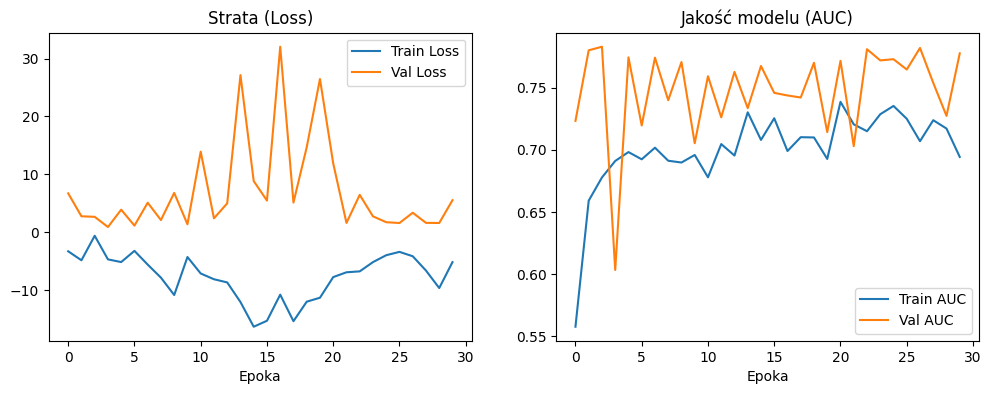

In [70]:
plt.figure(figsize=(12, 4))

# Wykres funkcji straty (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Strata (Loss)')
plt.xlabel('Epoka')
plt.legend()

# Wykres metryki AUC
plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('Jakość modelu (AUC)')
plt.xlabel('Epoka')
plt.legend()

plt.show()

1. First training
After first training model performed poorly, even after changing threshold from 0.8 to 0.5, learning rate from 0.01 to 0.005 to 0.0005 and increasing the batch size. Eventually model decided that the lowest loss it can achive is by ignoring all rain and resulting in almost zero recal: 0.0046.

The best recal model managed to get is around 0.2 with learning rate 0.005, batch size 64, epochs 30 and threshold 0.5.

In conclussion the model seems to complex for the one neuron to be able to train properly. The unbalanced dataset with small amount of rain might also be the issue and the model might need punishment for ignoring the rain cases.


2. After adding the dense 32 layer

**AUC** improved from 0.6 to 0.8 - the model can diffenciate the rain from no rain better

**Precision** improved from 0.4 to 0.6 - model finds less false alarms (false positive cases)

**Recall** still didn't improve and stays around 0.1 which means the unbalanced dataset is a real issue and the model needs a punishment for ignoring most of the rain cases

3. After adding class weights

After initially adding weights the model begin to be useless deciding to mark everything as rain

After changing RMS to Adam and lowering the threshold the model improved a little:

accuracy: 0.6519 - auc: 0.6961 - loss: -5.4004 - precision: 0.3063 - recall: 0.6107